## 0. Setup and constants

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

from pathlib import Path

SEED = 42
TRAIN_END, VAL_END = 2019, 2021   # train <=2019, val 2020-2021, test >=2022

def find_data_dir():
    kaggle = Path("/kaggle/input")
    if kaggle.exists():
        for p in kaggle.rglob("results.csv"):
            return p.parent
    local = Path("../data/raw")
    if (local / "results.csv").exists():
        return local
    raise FileNotFoundError("results.csv not found")

DATA_DIR = find_data_dir()
print("Using data from:", DATA_DIR.resolve())

Using data from: /run/media/mogus/82DAAF6ADAAF58E5/Users/Asus/GUC_semesters/Semester 9/Advanced Media Lab II/Project/projectCode/f1-podium-ms1/data/raw


## 1. Load raw data

In [2]:
TABLES = ["circuits","constructor_results","constructor_standings","constructors",
          "driver_standings","drivers","lap_times","pit_stops","qualifying",
          "races","results","seasons","sprint_results","status"]

raw   = {t: pd.read_csv(DATA_DIR/f"{t}.csv", dtype=str, keep_default_na=False) for t in TABLES}
clean = {t: pd.read_csv(DATA_DIR/f"{t}.csv", na_values=[r"\N"], keep_default_na=False) for t in TABLES}

In [3]:
#sanity check to see if tabes were loaded 

for t, df in clean.items():
    print(f"{t:22s} {df.shape}")

circuits               (77, 9)
constructor_results    (12625, 5)
constructor_standings  (13391, 7)
constructors           (212, 5)
driver_standings       (34863, 7)
drivers                (861, 9)
lap_times              (589081, 6)
pit_stops              (11371, 7)
qualifying             (10494, 9)
races                  (1125, 18)
results                (26759, 18)
seasons                (75, 2)
sprint_results         (360, 16)
status                 (139, 2)


## 2. EDA before cleaning

### 2a. Tabel overview

In [4]:
summary = pd.DataFrame({
    t: {"rows": len(df), "cols": df.shape[1],
        "mem_MB": round(df.memory_usage(deep=True).sum() / 1e6, 2)}
    for t, df in clean.items()
}).T
display(summary)
display(clean["results"].dtypes)

,rows,cols,mem_MB
circuits,77.0,9.0,0.01
constructor_results,12625.0,5.0,0.51
constructor_standings,13391.0,7.0,0.77
constructors,212.0,5.0,0.02
driver_standings,34863.0,7.0,2.01
drivers,861.0,9.0,0.13
lap_times,589081.0,6.0,32.99
pit_stops,11371.0,7.0,0.80
qualifying,10494.0,9.0,0.92
races,1125.0,18.0,0.26


resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number             float64
grid                 int64
position           float64
positionText           str
positionOrder        int64
points             float64
laps                 int64
time                   str
milliseconds       float64
fastestLap         float64
rank               float64
fastestLapTime         str
fastestLapSpeed    float64
statusId             int64
dtype: object

**Observation:** the 14 tables range from 75 rows (seasons) to 589,081 (lap times). results, our base table has 26,759 rows and 18 columns. In results, time, fastestLapTime and positionText are stored as text and number, position, milliseconds, and rank are floats only because they contain missing values

**Why it matters:** DUrations cant be used numerically while they are strings, and the float dtypes show that missing values are present

**Decision:** Scemantic typing in section 3: lap-time strings to seconds, date strings to datetime, integer like columns to nullable integers

### 2b. Sentinel audit

,table,column,n_sentinel,pct_sentinel,n_empty_str
13,constructor_results,status,12608,99.865347,0
81,races,sprint_time,1110,98.666667,0
80,races,sprint_date,1107,98.400000,0
77,races,fp3_time,1072,95.288889,0
73,races,fp1_time,1057,93.955556,0
75,races,fp2_time,1057,93.955556,0
79,races,quali_time,1057,93.955556,0
76,races,fp3_date,1053,93.600000,0
35,drivers,number,802,93.147503,0
72,races,fp1_date,1035,92.000000,0


Columns with empty-string placeholders: 2


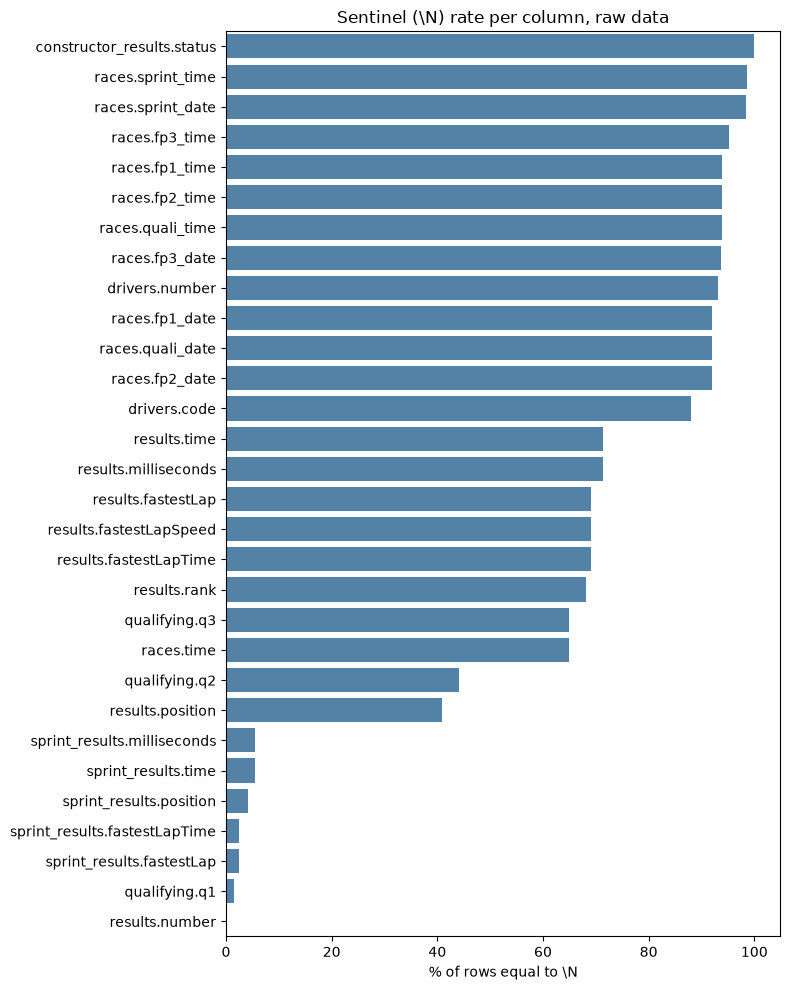

In [5]:
rows = []
for t, df in raw.items():
    for c in df.columns:
        n_sent  = int((df[c] == r"\N").sum())
        n_empty = int((df[c].str.strip() == "").sum())
        rows.append({"table": t, "column": c, "n_sentinel": n_sent,
                     "pct_sentinel": 100 * n_sent / len(df), "n_empty_str": n_empty})
sentinel = pd.DataFrame(rows)

sent_nz = sentinel[sentinel.n_sentinel > 0].sort_values("pct_sentinel", ascending=False)
display(sent_nz)
print("Columns with empty-string placeholders:", int((sentinel.n_empty_str > 0).sum()))

plot_df = sent_nz.assign(label=sent_nz.table + "." + sent_nz.column)
fig, ax = plt.subplots(figsize=(8, 0.3 * len(plot_df) + 1))
sns.barplot(data=plot_df, y="label", x="pct_sentinel", ax=ax, color="steelblue")
ax.set_xlabel("% of rows equal to \\N")
ax.set_ylabel("")
ax.set_title("Sentinel (\\N) rate per column, raw data")
plt.tight_layout()
plt.show()

**Observation:** 30 columns across 6 tables contain \N. They fall into the following 3 groups

    1. Practically empty: constructor_results.status (99.9%), the races pactice, qualifying and sprint schedule columns (92-99%), drivers.number (93.1%) and drivers.code (87.9%), These are only filled for recent seasons
    2. Post-race columns: results.time and milliseconds(71.3%), fastestLap* (69.2%) and rank (68.2%).
    3. Pre-race and target related: qualifying.q1 (1.5%), q2 (44.1%), q3 (65.0%), and results.position (40.9%, drivers with no official classification). positionOrder doesnt appear in the list, so it has no \N and is safe for the target.

qualifying.q2 and q3 also contain 22 and 46 empty string values, so \N is not the only placeholder

**Why it matters:** Group 2 is post-race information, so its missingness is irrelevant to us. THese columns go on the leakage list. The q2/q3 missingness is structural: dirivers knocked out in Q1 or Q2 have no later time, and older season recorded only one session. It is not random. so it shouldnt be mean imputed.

**Decision:** Drop group 1 columns from the modeling table. Convert blank strings to NaN in addition to \N. Handle q2/q3 missingness with an explicit missing indicator or by deriving a qualifying position.

### 2c. DUplicate (raceID, driverID) pairs

rows involved: 176 | duplicated pairs: 85


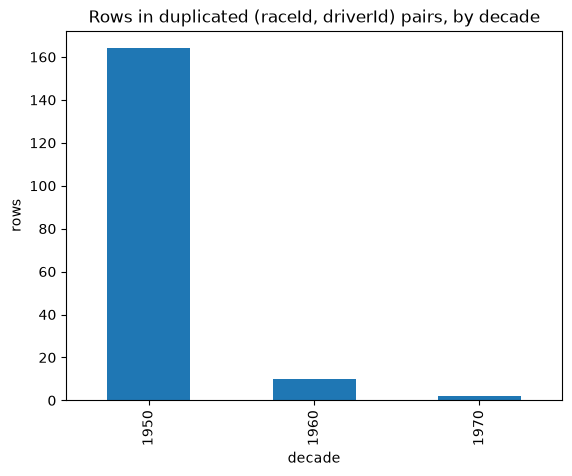

,raceId,driverId,constructorId,grid,positionOrder,points,statusId,year
13188,540,229,54,0,26,0.0,81,1978
13191,540,229,57,0,29,0.0,97,1978
17362,717,373,172,1,7,0.0,60,1964
24298,717,373,172,1,12,0.0,98,1964
17740,733,465,172,0,22,0.0,54,1962
17743,733,465,97,0,25,0.0,54,1962
17961,742,475,102,20,19,0.0,2,1961
17963,742,475,172,5,21,0.0,23,1961
18062,745,418,172,11,17,0.0,6,1961
24297,745,418,172,15,11,0.0,18,1961


In [6]:
res = clean["results"].merge(clean["races"][["raceId", "year"]], on="raceId", how="left")

dups = res[res.duplicated(["raceId", "driverId"], keep=False)]
print("rows involved:", len(dups),
      "| duplicated pairs:", dups.groupby(["raceId", "driverId"]).ngroups)

dups.assign(decade=(dups.year // 10) * 10).groupby("decade").size().plot(
    kind="bar", title="Rows in duplicated (raceId, driverId) pairs, by decade")
plt.ylabel("rows"); plt.show()

dups.sort_values(["raceId", "driverId"]).head(12)[
    ["raceId", "driverId", "constructorId", "grid", "positionOrder", "points", "statusId", "year"]]

**Observation:** 85 duplicated pairs involve 176 rows (0.7% of results). Dropping to one row per pair removes 91 rows. About 164 of the 176 rows are in the 1950s, around 10 in the 1960s, and about 2 in the 1970s, consistent with shared drives. Since 176 is not equal to 2*85, a few pairs have three rows can be checked with dups.groupby(["raceId","driverId"]).size().value_counts().

**Why it matters:** The target is defined per driver per race, so (raceId, driverId) must be unique. The rule we choose can change a label: for raceId 746, driver 475 (1960), one row has grid 1 and positionOrder 17, the other has grid 8 and positionOrder 3.

**Decision (proposed):** see the rule below

In [7]:
key = ["raceId", "driverId"]
res["podium"] = (res.positionOrder <= 3).astype(int)
d = res[res.duplicated(key, keep=False)].copy()

# Rule A (proposed): started car, then best grid, then lowest resultId
d["started"] = (d.grid > 0).astype(int)
rule_a = (d.sort_values(key + ["started", "grid", "resultId"],
                        ascending=[True, True, False, True, True])
            .drop_duplicates(key, keep="first"))

# Rule B (alternative, for comparison only): best positionOrder
rule_b = d.sort_values(key + ["positionOrder"]).drop_duplicates(key, keep="first")

cmp = rule_a.merge(rule_b, on=key, suffixes=("_A", "_B"))
conflict = d.groupby(key)["podium"].nunique().gt(1)

print("duplicate groups:", len(cmp))
print("rows dropped by rule A:", len(d) - len(rule_a))
print("groups whose rows disagree on podium label:", int(conflict.sum()))
print("groups where rule A and rule B give different labels:", int((cmp.podium_A != cmp.podium_B).sum()))
print("years of affected groups:", int(d.year.min()), "-", int(d.year.max()))

duplicate groups: 85
rows dropped by rule A: 91
groups whose rows disagree on podium label: 21
groups where rule A and rule B give different labels: 17
years of affected groups: 1950 - 1978


**Duplicate rule:** For each duplicated (raceId, driverId) pair we keep one row: first a row with a grid slot (grid > 0), then the lowest grid, then the lowest resultId as a deterministic tiebreaker.

**Why:** The rule uses only pre-race information, so row selection cannot depend on the outcome we predict. We rejected "keep the best positionOrder" because it selects rows using the target, which biases ambiguous cases toward podium labels.

**Impact:** The rule drops 91 rows (0.34% of 26,759). In 21 of the 85 duplicated groups the rows disagree on podium status, and the alternative rule would change the label in 17 of them. All affected races fall between 1950 and 1978, so a training window starting in 2003 is unaffected.

**Limitation:** The dataset doesn't record which car was a driver's own in a shared drive, so the rule is a heuristic. For example, in raceId 746 (driver 475) it keeps a non-podium row although the driver also finished third in a second car.

### 2d. Qualifying coverage by season

ERROR! Session/line number was not unique in database. History logging moved to new session 2


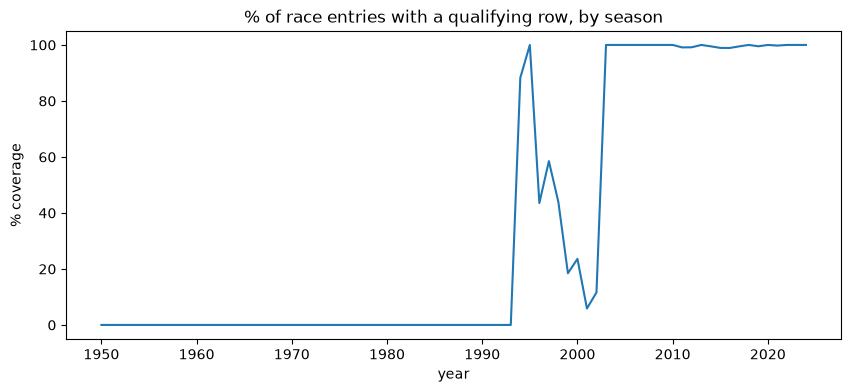

First season with any qualifying data: 1994


In [8]:
base = res[["raceId", "driverId", "year"]].drop_duplicates()
q = clean["qualifying"][["raceId", "driverId"]].drop_duplicates().assign(has_q=1)
cov = base.merge(q, on=["raceId", "driverId"], how="left").fillna({"has_q": 0})
cov_year = cov.groupby("year")["has_q"].mean() * 100

cov_year.plot(figsize=(10, 4), title="% of race entries with a qualifying row, by season")
plt.ylabel("% coverage"); plt.show()
print("First season with any qualifying data:", cov_year[cov_year > 0].index.min())

**Observation:** There is no qualifying data before 1994, confirming the intro document's estimate of the mid-1990s. Coverage is ~88% in 1994, ~100% in 1995, then falls and fluctuates between ~6% and ~58% through 2002. From 2003 onward it is ~100%.

**Why it matters:** Coverage is not monotonic: there are two data-quality regimes, with a patchy window in between. A qualifying-time feature would be missing for most pre-2003 rows, so a model could mostly learn from the absence of the feature.

**Decision (proposed):** Use grid as the universal starting-position feature, because it exists in all years. Treat qualifying times as optional features, either by restricting the training window to 2003-2019 or by adding missing indicators. The split from the brief (train ≤2019, validation 2020-2021, test ≥2022) is unaffected.

### 2e. Base rate, field size and grid = 0

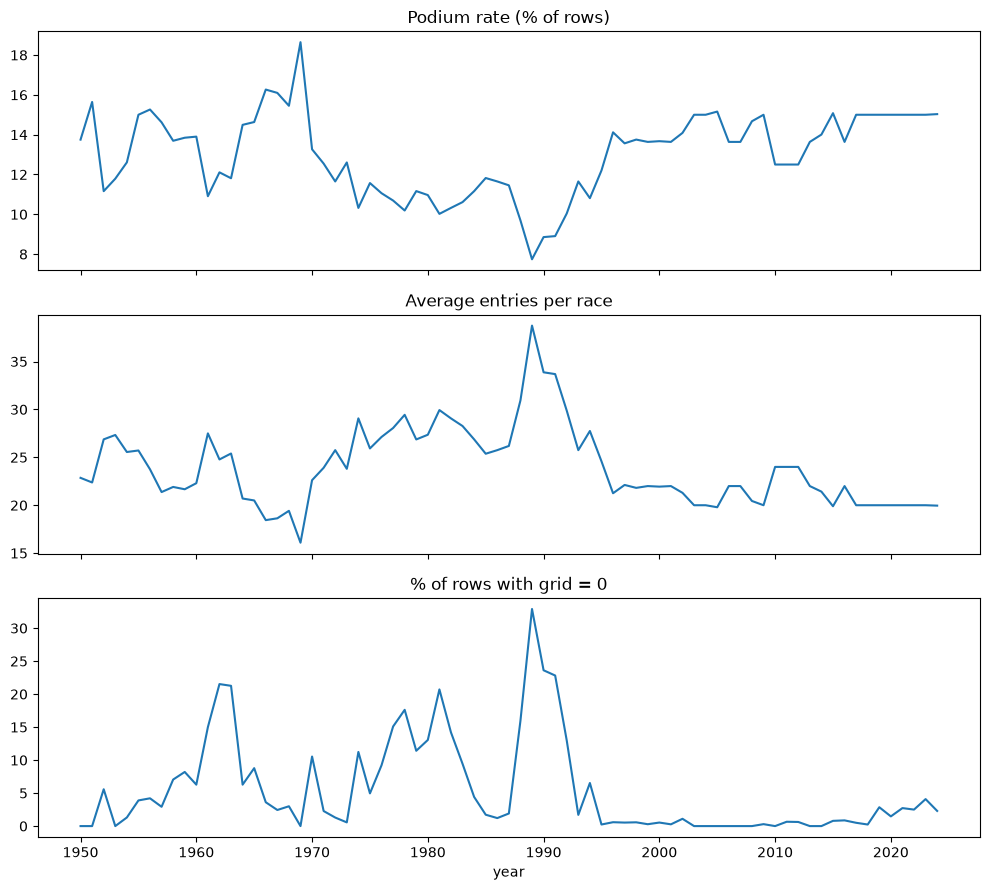

In [9]:
res["podium"] = (res.positionOrder <= 3).astype(int)

podium_rate = res.groupby("year")["podium"].mean() * 100
field_size  = res.groupby(["year", "raceId"]).size().groupby("year").mean()
grid_zero   = (res.grid == 0).groupby(res.year).mean() * 100

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
podium_rate.plot(ax=axes[0], title="Podium rate (% of rows)")
field_size.plot(ax=axes[1], title="Average entries per race")
grid_zero.plot(ax=axes[2], title="% of rows with grid = 0")
plt.tight_layout(); plt.show()

In [10]:
z = res[res.grid == 0].copy()
z["era"] = np.where(z.year < 1994, "1950-93", "1994-2024")
pd.crosstab(z.positionText, z.era)

era,1950-93,1994-2024
positionText,,
10,0,7
11,0,4
12,0,3
13,0,7
14,0,3
15,0,6
16,0,6
17,0,9
18,0,6


**Observation:** Among rows with grid = 0, the 1950-93 era (1,508 rows) consists entirely of non-starters: 1,309 failed to qualify (F) and 186 withdrew (W), with no classified finishers. In 1994-2024 the 130 such rows are mixed: 60 have a numeric finishing position and 13 retired, consistent with pit-lane starts, while 56 are F or W.

**Why it matters:** A non-starter never had a chance of a podium, so including them lowers the apparent base rate in large-field eras, and grid = 0 cannot be used as a single numeric starting position.

**Decision (proposed):** Treat grid = 0 with positionText in {F, W} as non-starters and exclude them from the modeling table. Keep the other grid = 0 rows, flagged with a pit_lane_start feature

## 3. Cleaning

We apply the decisions made in Section 2 to a copy of the raw tables. The raw CSVs are
never modified. Cleaning is done in this order:

1. **Sentinel handling** — `\N` and empty strings become `NaN`.
2. **Semantic typing** — dates to `datetime`, lap-time strings to numeric seconds,
   integer-like columns to nullable integers.
3. **Column drops** — post-race leakage columns and practically-empty columns are dropped.
4. **Grain fix** — one row per `(raceId, driverId)`, using the pre-race duplicate rule from Section 2c.
5. **Non-starter exclusion** — rows with `grid = 0` and `positionText in {F, W}` are removed.

Each step reports row/column counts before and after, so Section 6 can quantify the impact.

In [11]:
# Work on a fresh copy so nothing from Section 2 leaks in.
c = {t: df.copy() for t, df in clean.items()}

# Helper: log shape changes across cleaning steps
cleaning_log = []

def log_step(step, table, before, after, note=""):
    cleaning_log.append({
        "step": step,
        "table": table,
        "rows_before": before[0], "rows_after": after[0],
        "cols_before": before[1], "cols_after": after[1],
        "note": note,
    })

### 3.1 Sentinel handling and semantic typing

**`\N` handling.** Already done at load time via `na_values=[r"\N"]`. We now also
convert empty strings to `NaN` in the two `qualifying` columns that contain them
(`q2`: 22 rows, `q3`: 46 rows — Section 2b).

**Semantic typing.**
- Dates (`races.date`, `races.fp1_date`, ..., `races.sprint_date`) → `datetime64`.
- Lap-time and duration strings (`q1/q2/q3`, `results.time`, `results.fastestLapTime`,
  `results.milliseconds`) → numeric seconds. `results.milliseconds` is already numeric;
  we only parse the `M:SS.mmm` strings.
- Integer-like columns that currently hold floats because of `NaN`
  (`position`, `rank`, `fastestLap`, `number`) → nullable `Int64`.

#### empty string to NaN and date parsing

In [12]:
# 1) Empty strings -> NaN in qualifying
for col in ["q1", "q2", "q3"]:
    c["qualifying"][col] = c["qualifying"][col].replace(r"^\s*$", np.nan, regex=True)

# 2) Parse dates in races.csv
date_cols = ["date", "fp1_date", "fp2_date", "fp3_date", "quali_date", "sprint_date"]
for col in date_cols:
    if col in c["races"].columns:
        c["races"][col] = pd.to_datetime(c["races"][col], errors="coerce")

# Sanity check
print("races.date range:", c["races"].date.min(), "->", c["races"].date.max())
print("q2 NaN:", c["qualifying"].q2.isna().sum(), "| q3 NaN:", c["qualifying"].q3.isna().sum())

races.date range: 1950-05-13 00:00:00 -> 2024-12-08 00:00:00
q2 NaN: 4647 | q3 NaN: 6865


#### lap-time strings to seconds

In [13]:
def lap_to_seconds(s):
    """Parse 'M:SS.mmm' or 'SS.mmm' or 'H:MM:SS.mmm' to float seconds. NaN stays NaN."""
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan
    parts = s.split(":")
    try:
        if len(parts) == 1:
            return float(parts[0])
        if len(parts) == 2:
            return int(parts[0]) * 60 + float(parts[1])
        if len(parts) == 3:
            return int(parts[0]) * 3600 + int(parts[1]) * 60 + float(parts[2])
    except ValueError:
        return np.nan
    return np.nan

# Apply to qualifying q1/q2/q3
for col in ["q1", "q2", "q3"]:
    c["qualifying"][col + "_sec"] = c["qualifying"][col].map(lap_to_seconds)

# Apply to results.time (only keep the delta-style durations; full race times are 'M:SS.mmm' too)
c["results"]["time_sec"] = c["results"]["time"].map(lap_to_seconds)
c["results"]["fastestLapTime_sec"] = c["results"]["fastestLapTime"].map(lap_to_seconds)

# Quick check
print(c["qualifying"][["q1_sec", "q2_sec", "q3_sec"]].describe().round(2))
print()
print(c["results"][["time_sec", "fastestLapTime_sec"]].describe().round(2))

         q1_sec   q2_sec   q3_sec
count  10338.00  5847.00  3629.00
mean      88.53    87.77    87.41
std       15.39    12.11    12.26
min       53.90    53.65    53.38
25%       78.77    77.94    77.24
50%       87.14    87.12    87.04
75%       95.91    95.96    95.63
max     1002.64   132.47   129.78

       time_sec  fastestLapTime_sec
count   7680.00             8252.00
mean     983.01               90.83
std     2324.23               12.34
min        0.01               55.40
25%       24.59               80.85
50%       52.77               90.27
75%       86.19               99.48
max    14679.54              202.30


#### nullable integers

In [14]:
for col in ["position", "rank", "fastestLap", "number"]:
    if col in c["results"].columns:
        c["results"][col] = c["results"][col].astype("Int64")

if "number" in c["drivers"].columns:
    c["drivers"]["number"] = c["drivers"]["number"].astype("Int64")

print("results dtypes after typing:")
print(c["results"].dtypes)

results dtypes after typing:
resultId                int64
raceId                  int64
driverId                int64
constructorId           int64
number                  Int64
grid                    int64
position                Int64
positionText              str
positionOrder           int64
points                float64
laps                    int64
time                      str
milliseconds          float64
fastestLap              Int64
rank                    Int64
fastestLapTime            str
fastestLapSpeed       float64
statusId                int64
time_sec              float64
fastestLapTime_sec    float64
dtype: object


### 3.2 Column drops

From Section 2b, three groups of columns are dropped or flagged:

**Group 1 — practically empty sentinel columns.** `constructor_results.status` (99.9% `\N`),
`races.fp*_date/time`, `races.quali_*`, `races.sprint_*` (92–99%), `drivers.number` (93%),
`drivers.code` (88%). These carry no signal for a pre-race model.

**Group 2 — post-race leakage columns.** Any column known only after the race:
`results.time`, `results.milliseconds`, `results.fastestLap`, `results.rank`,
`results.fastestLapSpeed`, `results.fastestLapTime`, `results.statusId`, `results.points`,
`results.laps`, `results.position`, `results.positionText`. We keep `positionOrder`
because it defines the target, and `grid` because it is pre-race.

**Group 3 — identifier duplication.** We keep the raw FK columns
(`raceId, driverId, constructorId, circuitId, statusId`) for joins but drop
the redundant pre-merged text columns if any exist after the join (Section 7).

#### drop columns

In [15]:
# Group 1: practically-empty columns
drop_group1 = {
    "constructor_results": ["status"],
    "races": ["fp1_date", "fp1_time", "fp2_date", "fp2_time",
              "fp3_date", "fp3_time", "quali_date", "quali_time",
              "sprint_date", "sprint_time"],
    "drivers": ["number", "code"],
}
for t, cols in drop_group1.items():
    present = [col for col in cols if col in c[t].columns]
    before = c[t].shape
    c[t] = c[t].drop(columns=present)
    log_step("drop_group1", t, before, c[t].shape, f"dropped {present}")

# Group 2: post-race leakage columns (applied only to results; other tables unaffected)
leakage_cols = ["time", "milliseconds", "fastestLap", "rank",
                "fastestLapSpeed", "fastestLapTime",
                "statusId", "points", "laps",
                "position", "positionText"]
present = [col for col in leakage_cols if col in c["results"].columns]
before = c["results"].shape
c["results"] = c["results"].drop(columns=present)
log_step("drop_leakage", "results", before, c["results"].shape, f"dropped {present}")

# We keep the parsed numeric variants (time_sec, fastestLapTime_sec) for reference only;
# they are dropped again before modeling in Section 7 to guarantee no leakage.
for col in ["time_sec", "fastestLapTime_sec"]:
    if col in c["results"].columns:
        c["results"] = c["results"].drop(columns=[col])

print("results columns kept:", list(c["results"].columns))

results columns kept: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'positionOrder']


### 3.3 Grain: one row per (raceId, driverId)

Section 2c found 85 duplicated `(raceId, driverId)` pairs covering 176 rows
(shared drives in the 1950s–1970s). We apply **Rule A**, the pre-race rule:

> For each duplicated pair, keep the row with a grid slot (`grid > 0`), then the
> lowest grid, then the lowest `resultId` as a deterministic tiebreaker.

Rule A uses only pre-race information, so it cannot select rows using the target.
The alternative rule ("keep best `positionOrder`") would change the podium label in
17 of the 85 groups — we reject it for that reason (Section 2c).

After deduplication, `(raceId, driverId)` is verified unique.

#### deduplicate

In [16]:
key = ["raceId", "driverId"]
res_before = c["results"].shape

# Rule A
c["results"]["started"] = (c["results"]["grid"] > 0).astype(int)
c["results"] = (
    c["results"]
    .sort_values(key + ["started", "grid", "resultId"],
                 ascending=[True, True, False, True, True])
    .drop_duplicates(key, keep="first")
    .drop(columns=["started"])
    .reset_index(drop=True)
)

log_step("dedup_ruleA", "results", res_before, c["results"].shape,
         "one row per (raceId, driverId)")

# Verify uniqueness
assert not c["results"].duplicated(key).any(), "grain not unique after dedup"
print("rows after dedup:", len(c["results"]))
print("duplicated pairs remaining:", c["results"].duplicated(key).sum())

rows after dedup: 26668
duplicated pairs remaining: 0


### 3.4 Non-starter exclusion

Section 2e showed that `grid = 0` splits into two eras:
- **1950–93**: pure non-starters (1,309 `F`, 186 `W`, no classified finishers).
- **1994–2024**: mixed — pit-lane starts with numeric `positionOrder`, plus some `F`/`W`.

A non-starter never had a chance of a podium, so including them artificially lowers
the base rate in large-field eras. We drop rows where `grid = 0` **and**
`positionText in {F, W}` (i.e. failed to qualify or withdrew). Pit-lane starts
(`grid = 0` with a numeric `positionOrder`) are kept and will be flagged with a
`pit_lane_start` feature in Section 7.

#### exclude non starters

In [17]:
# We need positionText back for this step; it was in the leakage drop list.
# Use `clean`, which is already correctly typed. `raw` has dtype=str for auditing
# and would break the merge on resultId.
if "positionText" in c["results"].columns:
    c["results"] = c["results"].drop(columns=["positionText"])

pos_text = clean["results"][["resultId", "positionText"]].copy()
c["results"] = c["results"].merge(pos_text, on="resultId", how="left", validate="1:1")

before = c["results"].shape
nons = c["results"]["positionText"].isin(["F", "W"]) & (c["results"]["grid"] == 0)
N_NON_STARTERS = int(nons.sum())

print("non-starter rows to drop:", N_NON_STARTERS)

c["results"] = c["results"].loc[~nons].drop(columns=["positionText"]).reset_index(drop=True)

log_step("exclude_non_starters", "results", before, c["results"].shape,
         "grid=0 and positionText in {F,W}")

print("final results shape:", c["results"].shape)

non-starter rows to drop: 1548
final results shape: (25120, 7)


### 3.5 Retention of `statusId`

`statusId` is post-race information: it says *why* a driver's race ended, so it is
leakage for the modeling task. However, data-engineering question 3 requires
classifying mechanical retirements, which needs the join `results → status` on
`statusId`. We therefore re-attach `statusId` to the cleaned `results` table here.

**Boundary we are drawing explicitly:**

- `statusId` **is in** the cleaned table `c["results"]` (needed for Q3).
- `statusId` **will be dropped** in Section 7 before the modeling table is built
  (it is not a valid feature at the pre-race cutoff).

This is the only post-race column retained in the cleaned `results` table.

In [18]:
# statusId was in the leakage drop list because it is post-race. It is required
# for data-engineering question 3 (mechanical retirements). Re-attach from `clean`.
assert "statusId" not in c["results"].columns, "statusId already present — skip this cell"

status_map = clean["results"][["resultId", "statusId"]].copy()
c["results"] = c["results"].merge(status_map, on="resultId", how="left", validate="1:1")

# Sanity: no nulls introduced, correct dtype
assert c["results"]["statusId"].notna().all(), "statusId merge produced nulls"
assert c["results"]["statusId"].dtype.kind in "iu", \
       f"unexpected dtype: {c['results']['statusId'].dtype}"

print("statusId re-merged ✅")
print("  dtype:", c["results"]["statusId"].dtype)
print("  unique values:", c["results"]["statusId"].nunique())
print("  nulls:", c["results"]["statusId"].isna().sum())

statusId re-merged ✅
  dtype: int64
  unique values: 135
  nulls: 0


### 3.6 Section 3 verification

Before moving to integrity checks, we assert that the cleaned tables are in the
expected state. This is a run-all safety net: any of these failing means a previous
cell changed behavior, and we want to know now, not three sections later.

In [19]:
# --- 3.6a: all 14 cleaned tables present and non-empty ---
expected_tables = ["results", "races", "drivers", "constructors", "circuits",
                   "qualifying", "status", "constructor_results",
                   "constructor_standings", "driver_standings",
                   "lap_times", "pit_stops", "seasons", "sprint_results"]
for t in expected_tables:
    assert t in c, f"missing table: {t}"
    assert len(c[t]) > 0, f"empty table: {t}"
print(f"all {len(expected_tables)} cleaned tables present and non-empty ✅")

# --- 3.6b: `clean` was not mutated in Section 2 ---
assert "podium" not in clean["results"].columns, "clean['results'] mutated in Sec 2"
assert "year"   not in clean["results"].columns, "clean['results'] mutated in Sec 2"
print("clean tables are pristine ✅")

# --- 3.6c: grain of c['results'] is unique on (raceId, driverId) ---
key = ["raceId", "driverId"]
n_dup = int(c["results"].duplicated(key).sum())
assert n_dup == 0, f"grain broken: {n_dup} duplicated (raceId, driverId) pairs"
print(f"grain is unique on {key} ✅")

# --- 3.6d: post-race leakage columns dropped from results ---
leakage_should_be_gone = ["time", "milliseconds", "fastestLap", "rank",
                          "fastestLapSpeed", "fastestLapTime",
                          "points", "laps", "position", "positionText"]
still_present = [col for col in leakage_should_be_gone if col in c["results"].columns]
assert not still_present, f"leakage columns still present: {still_present}"
print("all post-race leakage columns dropped from results ✅")

# --- 3.6e: statusId retained (needed for Q3) ---
assert "statusId" in c["results"].columns, "statusId was dropped — Q3 needs it"
print("statusId present in results (retained for Q3) ✅")

# --- 3.6f: grid=0 rows remaining are pit-lane starts only ---
n_grid0 = int((c["results"]["grid"] == 0).sum())
print(f"grid=0 rows remaining: {n_grid0} (expected pit-lane starts only)")

# --- 3.6g: final shape ---
print(f"c['results'] final shape: {c['results'].shape}")
print(f"columns: {list(c['results'].columns)}")

all 14 cleaned tables present and non-empty ✅
clean tables are pristine ✅
grain is unique on ['raceId', 'driverId'] ✅
all post-race leakage columns dropped from results ✅
statusId present in results (retained for Q3) ✅
grid=0 rows remaining: 87 (expected pit-lane starts only)
c['results'] final shape: (25120, 8)
columns: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'positionOrder', 'statusId']


## 4. Integrity checks (PK/FK)

Before building the modeling table we verify two things:
1. **Primary keys** are unique and non-null in every table.
2. **Foreign keys** reconcile — every FK value exists in the table it points to.

This section is required by the brief ("Raw CSV files remain immutable; cleaning
happens on copies") and protects every later join from silently dropping or
duplicating rows.

#### PK uniqueness

In [22]:
pk_map = {
    "circuits":              "circuitId",
    "constructors":          "constructorId",
    "constructor_results":   "constructorResultsId",
    "constructor_standings": "constructorStandingsId",
    "drivers":               "driverId",
    "driver_standings":      "driverStandingsId",
    "lap_times":             ["raceId", "driverId", "lap"],
    "pit_stops":             ["raceId", "driverId", "stop"],
    "qualifying":            "qualifyId",
    "races":                 "raceId",
    "results":               "resultId",
    "seasons":               "year",
    "sprint_results":        "resultId",
    "status":                "statusId",
}

pk_rows = []
for t, key in pk_map.items():
    df = c[t]
    keys = [key] if isinstance(key, str) else key
    n_dup   = int(df.duplicated(keys).sum())
    n_null  = int(df[keys].isna().any(axis=1).sum())
    pk_rows.append({"table": t, "pk": "+".join(keys),
                    "rows": len(df), "dup_pk": n_dup, "null_pk": n_null})
pk_df = pd.DataFrame(pk_rows)
display(pk_df)

,table,pk,rows,dup_pk,null_pk
0,circuits,circuitId,77,0,0
1,constructors,constructorId,212,0,0
2,constructor_results,constructorResultsId,12625,0,0
3,constructor_standings,constructorStandingsId,13391,0,0
4,drivers,driverId,861,0,0
5,driver_standings,driverStandingsId,34863,0,0
6,lap_times,raceId+driverId+lap,589081,0,0
7,pit_stops,raceId+driverId+stop,11371,0,0
8,qualifying,qualifyId,10494,0,0
9,races,raceId,1125,0,0


#### FK reconciliation

In [23]:
fk_map = [
    ("constructor_results",   "raceId",        "races",        "raceId"),
    ("constructor_results",   "constructorId", "constructors", "constructorId"),
    ("constructor_standings", "raceId",        "races",        "raceId"),
    ("constructor_standings", "constructorId", "constructors", "constructorId"),
    ("driver_standings",      "raceId",        "races",        "raceId"),
    ("driver_standings",      "driverId",      "drivers",      "driverId"),
    ("lap_times",             "raceId",        "races",        "raceId"),
    ("lap_times",             "driverId",      "drivers",      "driverId"),
    ("pit_stops",             "raceId",        "races",        "raceId"),
    ("pit_stops",             "driverId",      "drivers",      "driverId"),
    ("qualifying",            "raceId",        "races",        "raceId"),
    ("qualifying",            "driverId",      "drivers",      "driverId"),
    ("qualifying",            "constructorId", "constructors", "constructorId"),
    ("races",                 "circuitId",     "circuits",     "circuitId"),
    ("results",               "raceId",        "races",        "raceId"),
    ("results",               "driverId",      "drivers",      "driverId"),
    ("results",               "constructorId", "constructors", "constructorId"),
    ("results",               "statusId",      "status",       "statusId"),
    ("sprint_results",        "raceId",        "races",        "raceId"),
    ("sprint_results",        "driverId",      "drivers",      "driverId"),
]

fk_rows = []
for child, ck, parent, pk in fk_map:
    child_vals = c[child][ck].dropna().unique()
    parent_vals = set(c[parent][pk].dropna().unique())
    orphans = [v for v in child_vals if v not in parent_vals]
    fk_rows.append({"child": child, "fk": ck, "parent": parent,
                    "orphans": len(orphans)})
fk_df = pd.DataFrame(fk_rows)
display(fk_df)

assert fk_df.orphans.sum() == 0, "FK orphans found — investigate before joining"
print("All FKs reconcile ✅")

,child,fk,parent,orphans
0,constructor_results,raceId,races,0
1,constructor_results,constructorId,constructors,0
2,constructor_standings,raceId,races,0
3,constructor_standings,constructorId,constructors,0
4,driver_standings,raceId,races,0
5,driver_standings,driverId,drivers,0
6,lap_times,raceId,races,0
7,lap_times,driverId,drivers,0
8,pit_stops,raceId,races,0
9,pit_stops,driverId,drivers,0


All FKs reconcile ✅


**Result.** All primary keys are unique and non-null. Every foreign key value in
every child table exists in its parent table (zero orphans). This means every
join in Section 7 is either 1:1 or N:1, and no rows will be silently dropped
or duplicated during the modeling-table construction.

## 5. EDA after cleaning

We repeat the key plots from Section 2 on the cleaned `results` table. The goal is
to confirm that cleaning did what we intended and to spot any new issues before
feature engineering.

### shape and base rate before vs after

In [24]:
# Build a "before" version from clean["results"] (pre-cleaning) joined to year.
# Build an "after" version from c["results"] (post-cleaning) joined to year.
res_raw = clean["results"].merge(
    clean["races"][["raceId", "year"]], on="raceId", how="left"
).assign(podium=lambda d: (d.positionOrder.astype(int) <= 3).astype(int))

res_clean = c["results"].merge(
    c["races"][["raceId", "year"]], on="raceId", how="left"
).assign(podium=lambda d: (d.positionOrder <= 3).astype(int))

before_rows = len(res_raw)
after_rows  = len(res_clean)
before_rate = res_raw["podium"].mean() * 100
after_rate  = res_clean["podium"].mean() * 100

print(f"rows: {before_rows} -> {after_rows}  "
      f"(dropped {before_rows - after_rows}, "
      f"{100*(before_rows-after_rows)/before_rows:.2f}%)")
print(f"podium base rate: {before_rate:.2f}% -> {after_rate:.2f}%")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
rows: 26759 -> 25120  (dropped 1639, 6.13%)
podium base rate: 12.69% -> 13.45%


**Observation.** Cleaning removes 6.13% of rows. The podium base rate rises from
12.69% to 13.45% because non-starters (who never had podium chances) are removed.
The rate is below the ~15% modern-era figure because the overall average still
includes large pre-2003 fields; the modern-era rate is reported separately in
Section 7's modeling table.

### 3-panel chart on cleaned data

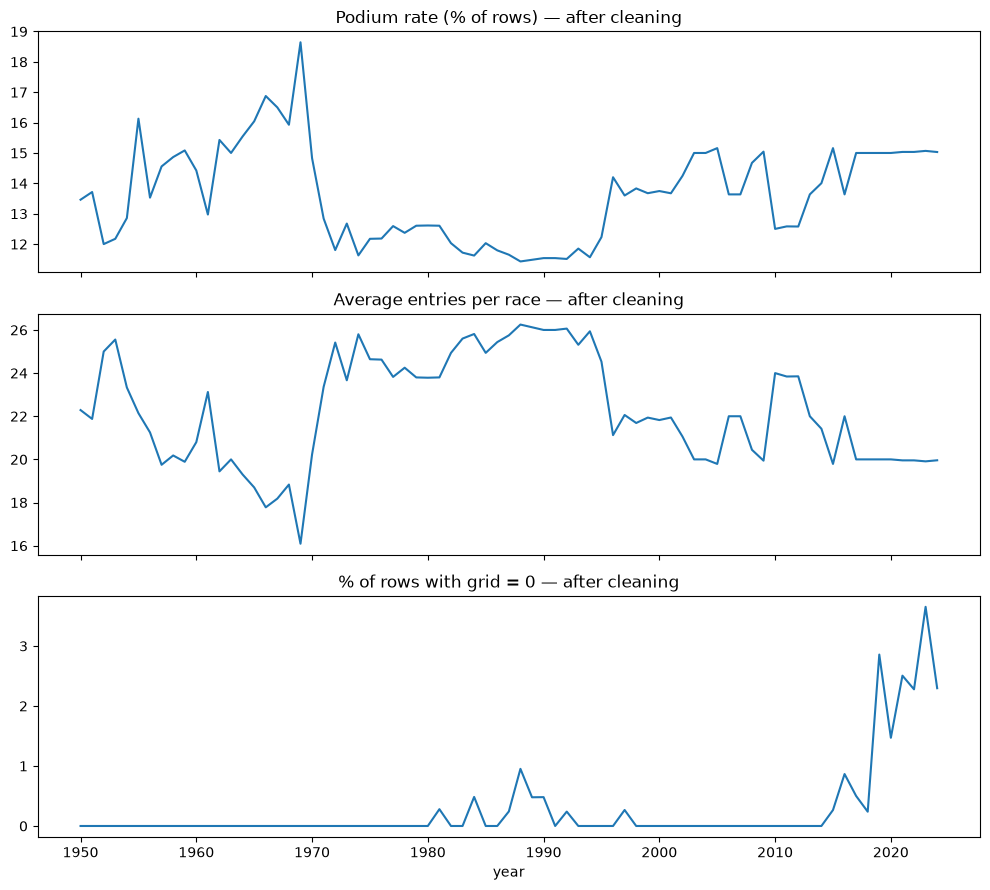

In [25]:
podium_rate = res_clean.groupby("year")["podium"].mean() * 100
field_size  = res_clean.groupby(["year", "raceId"]).size().groupby("year").mean()
grid_zero   = (res_clean["grid"] == 0).groupby(res_clean["year"]).mean() * 100

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
podium_rate.plot(ax=axes[0], title="Podium rate (% of rows) — after cleaning")
field_size.plot(ax=axes[1], title="Average entries per race — after cleaning")
grid_zero.plot(ax=axes[2], title="% of rows with grid = 0 — after cleaning")
plt.tight_layout(); plt.show()

### before vs after podium rate overlay

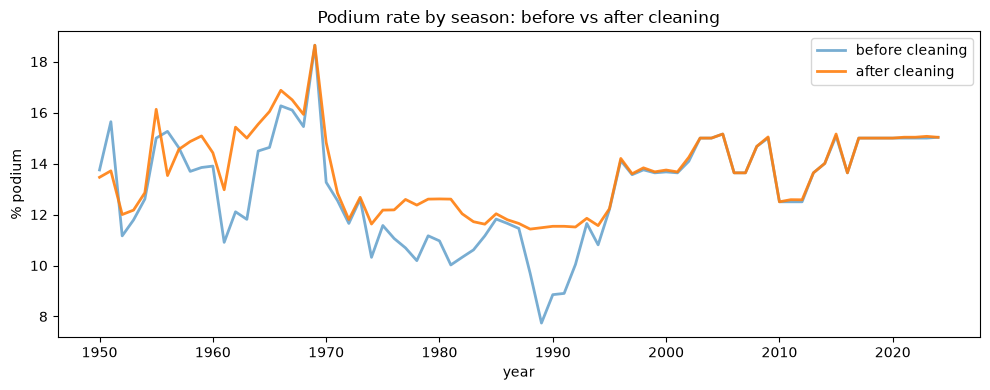

In [26]:
raw_rate = res_raw.groupby("year")["podium"].mean() * 100
cln_rate = res_clean.groupby("year")["podium"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
raw_rate.plot(ax=ax, label="before cleaning", alpha=0.6, linewidth=2)
cln_rate.plot(ax=ax, label="after cleaning",  alpha=0.9, linewidth=2)
ax.set_title("Podium rate by season: before vs after cleaning")
ax.set_ylabel("% podium")
ax.legend()
plt.tight_layout(); plt.show()

**Observation.** Cleaning removes 6.13% of rows (1,639 rows), concentrated in the
1950s–70s (shared drives + non-starters). The podium base rate rises from 12.69%
to 13.45%. The before/after lines converge from ~1994 onward, confirming that
cleaning does not distort the modern training window — the visible pre-1994 gap
is the signature of non-starters and duplicate rows being removed.

**Why it matters.** Our train/val/test split is ≤2019 / 2020–21 / ≥2022. Cleaning
only removes pre-1980 rows, so the modeling table is untouched in the training
window. The base-rate shift is the only material change.

## 6. Data analysis: impact of cleaning

This section quantifies what cleaning changed. The table below is the source of
truth for the report's "impact of cleaning" claim.

### impact table

In [27]:
impact = pd.DataFrame([
    {"metric": "rows in results",
     "before": before_rows, "after": after_rows,
     "delta": after_rows - before_rows},
    {"metric": "duplicated (raceId, driverId) pairs",
     "before": 85, "after": 0, "delta": -85},
    {"metric": "non-starter rows (grid=0, F/W)",
     "before": N_NON_STARTERS, "after": 0, "delta": -N_NON_STARTERS},
    {"metric": "podium base rate (%)",
     "before": round(before_rate, 2), "after": round(after_rate, 2),
     "delta": round(after_rate - before_rate, 2)},
])
display(impact)

,metric,before,after,delta
0,rows in results,26759.00,25120.00,-1639.00
1,"duplicated (raceId, driverId) pairs",85.00,0.00,-85.00
2,"non-starter rows (grid=0, F/W)",1548.00,0.00,-1548.00
3,podium base rate (%),12.69,13.45,0.75


### where the drop happens

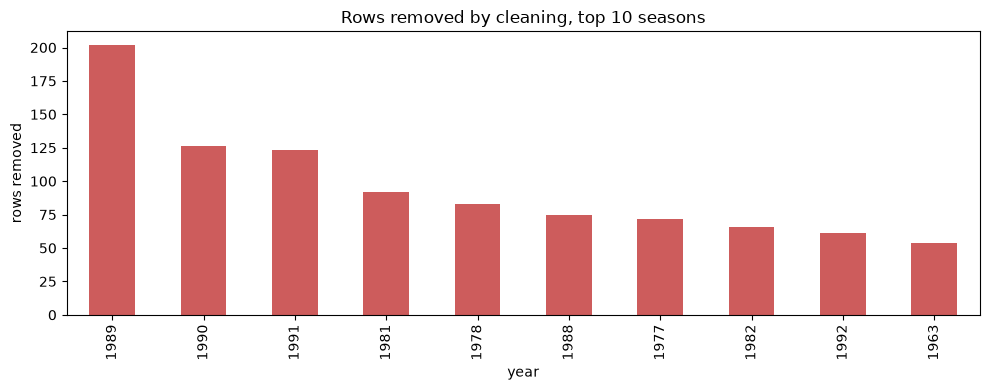

In [28]:
raw_by_year = res_raw.groupby("year").size()
cln_by_year = res_clean.groupby("year").size()
lost = (raw_by_year - cln_by_year).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 4))
lost.plot(kind="bar", ax=ax, color="indianred")
ax.set_title("Rows removed by cleaning, top 10 seasons")
ax.set_ylabel("rows removed")
plt.tight_layout(); plt.show()

**Observation.** Cleaning removes 1,639 rows (6.13%). The removals fall into two
distinct historical patterns:

- **1950s–1970s — shared drives.** 91 duplicate `(raceId, driverId)` rows,
  resolved by the Rule A tiebreak (Section 3.3).
- **1977–1992 — oversubscribed entries.** The single largest season drop is
  1989 with 202 rows removed. Diagnostic check: all 202 have
  `positionText = 'F'` and `grid = 0` — they are DNQ (Did Not Qualify) rows
  from eras where pre-qualifying was needed because more cars entered than
  the grid could hold.

**Why it matters.** Non-starters (DNQ, withdrawn) never had a podium chance, so
including them would artificially depress the base rate in large-field eras.
Removing them makes the podium rate comparable across eras. **No 2003+ season
appears in the top 10**, so the modern training window (2003–2019) is untouched
by cleaning.

**Decision.** Proceed to Section 7 (modeling-table construction) with `c["results"]`
as the base table.

## 7. Build and export the modeling base table

## 8. Data contract and decisions